# Research Study 001
## Covariance Estimation and Out-of-Sample Performance of Cryptocurrency GMV Portfolios

### Research Question

Does the choice of covariance estimator affect the out-of-sample
risk and risk-adjusted performance of a cryptocurrency Global
Minimum Variance (GMV) portfolio?

### Investment Decision

A quantitative portfolio manager must select a covariance estimator
when constructing a diversified cryptocurrency GMV portfolio.

The objective of this study is to determine whether the choice of
covariance methodology materially affects:

- portfolio return,
- portfolio volatility,
- risk-adjusted performance,
- drawdown,
- turnover,
- and implementation costs.

The final objective is not merely to identify the estimator with
the highest historical performance, but to determine whether the
evidence supports a robust investment recommendation.

### Hypotheses

**H1:** Covariance-estimation methodology affects the out-of-sample
risk characteristics of a GMV portfolio.

**H2:** Covariance-estimation methodology affects out-of-sample
risk-adjusted performance.

**H3:** Covariance regularization may improve portfolio stability,
potentially reflected in volatility, drawdown, turnover, or
risk-adjusted performance.

The hypotheses are non-directional. No covariance methodology is
assumed to be superior before the experiment.

---

### Experimental Protocol

| Component | Specification |
|---|---|
| Universe | BTC, ETH, SOL |
| Frequency | Daily |
| Requested period | 2021-01-01 to 2025-12-31 |
| Actual common period | Determined after synchronization |
| Portfolio | Global Minimum Variance |
| Validation | Expanding walk-forward |
| Training window | 252 observations |
| Test window | 21 observations |
| Sample covariance | Yes |
| Shrinkage covariance | λ = 0.25 |
| Ledoit-Wolf | Yes |
| Annualization | 365 |
| Risk-free rate | 0% |

All methodological parameters are fixed before examining the
performance results.

## Research Integrity Statement

The study follows a strictly out-of-sample walk-forward design.

For each fold, covariance estimation and portfolio construction use
training-period information only. Portfolio performance is then
measured on the subsequent test period.

The baseline specification is fixed before evaluating the comparative
results. Subsequent parameter changes will be treated as explicit
robustness experiments rather than incorporated into the baseline
analysis.

This separation is intended to reduce look-ahead bias, data leakage,
and result-driven specification changes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from crypto_alpha_lab.data import load_prices

ASSETS = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
}

START_DATE = "2021-01-01"
END_DATE = "2025-12-31"

prices = {}

for name, ticker in ASSETS.items():
    prices[name] = load_prices(
        ticker=ticker,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        refresh=False,
    )

In [2]:
# Research parameters

ASSETS = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
}

START_DATE = "2021-01-01"
END_DATE = "2025-12-31"

TRAIN_SIZE = 252
TEST_SIZE = 21

SHRINKAGE = 0.25

PERIODS_PER_YEAR = 365
RISK_FREE_RATE = 0.0

"""
Because these are cryptocurrency markets, daily observations occur seven days per week.
Therefore, we use number of period of 365 rather than the equity-market 
convention of 252 per year.
"""

EXPANDING = True

In [3]:
# Construct the research Universe

close_prices = pd.concat(
    {
        name: data["Close"]
        for name, data in prices.items()
    },
    axis=1,
).dropna()

close_prices.index.name = "Date"

close_prices

,BTC,ETH,SOL
Date,,,
2021-01-01,29374.152344,730.367554,1.842084
2021-01-02,32127.267578,774.534973,1.799275
2021-01-03,32782.023438,975.507690,2.161752
2021-01-04,31971.914062,1040.233032,2.485097
2021-01-05,33992.429688,1100.006104,2.157217
...,...,...,...
2025-12-26,87301.429688,2925.745605,122.195953
2025-12-27,87802.156250,2947.998291,124.647713
2025-12-28,87835.835938,2948.568115,125.199356


In [4]:
# We construct the sychronized close prices matrix 
# by concatenating the "Close" prices for each asset in ASSETS.

assert list(close_prices.columns) == ["BTC","ETH","SOL",]

assert close_prices.index.is_monotonic_increasing
assert not close_prices.index.has_duplicates

assert np.isfinite(
    close_prices.to_numpy(dtype=float)
).all()

print("Shape:", close_prices.shape)
print("Start:", close_prices.index.min())
print("End:", close_prices.index.max())

Shape: (1825, 3)
Start: 2021-01-01 00:00:00
End: 2025-12-30 00:00:00


In [5]:
# Price validation
# We perform some basic sanity checks on the close prices DataFrame as well as validate the dataset

assert list(close_prices.columns) == [
    "BTC",
    "ETH",
    "SOL",
]

assert not close_prices.empty
assert close_prices.index.is_monotonic_increasing
assert not close_prices.index.has_duplicates

assert np.isfinite(
    close_prices.to_numpy(dtype=float)
).all()

print("Shape:", close_prices.shape)
print("Start:", close_prices.index.min())
print("End:", close_prices.index.max())
print("Assets:", close_prices.columns.tolist())

Shape: (1825, 3)
Start: 2021-01-01 00:00:00
End: 2025-12-30 00:00:00
Assets: ['BTC', 'ETH', 'SOL']


In [6]:
# Freezing the dataset metadata for reproducibility and validation purposes.

DATASET_METADATA = {
    "assets": list(close_prices.columns),
    "requested_start": START_DATE,
    "requested_end": END_DATE,
    "actual_start": str(close_prices.index.min().date()),
    "actual_end": str(close_prices.index.max().date()),
    "observation_count": len(close_prices),
    "frequency": "daily",
}

pd.Series(DATASET_METADATA)

assets               [BTC, ETH, SOL]
requested_start           2021-01-01
requested_end             2025-12-31
actual_start              2021-01-01
actual_end                2025-12-30
observation_count               1825
frequency                      daily
dtype: object

In [7]:
# we investigate basic return statistics

returns = close_prices.pct_change().dropna()

return_summary = pd.DataFrame(
    {
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "annualized_return": (
            (1 + returns.mean()) ** PERIODS_PER_YEAR - 1
        ),
        "annualized_volatility": (
            returns.std() * np.sqrt(PERIODS_PER_YEAR)
        ),
    }
)

return_summary

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility
BTC,0.001072,0.030601,0.478498,0.584623
ETH,0.001619,0.041260,0.804840,0.788272
SOL,0.004081,0.059611,3.422179,1.138858


In [8]:
# Return corrrelations

correlation_matrix = returns.corr()

correlation_matrix

,BTC,ETH,SOL
BTC,1.000000,0.805702,0.603115
ETH,0.805702,1.000000,0.646474
SOL,0.603115,0.646474,1.000000


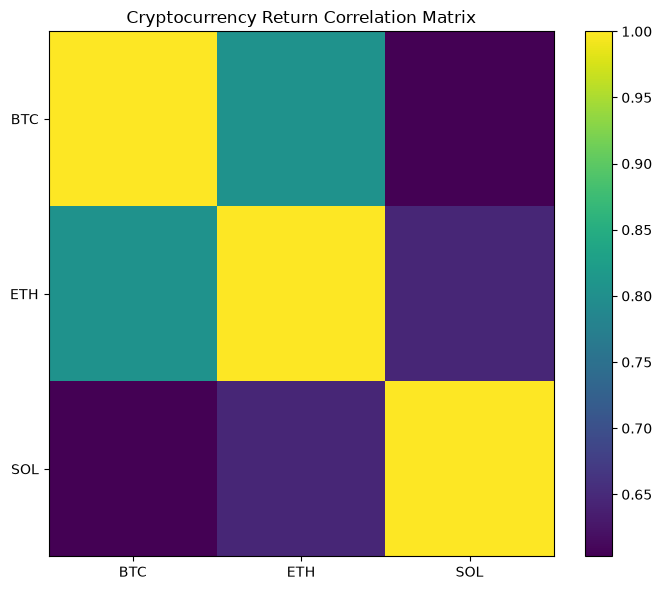

In [9]:
# We plot the correlation matrix for the returns of the assets in ASSETS.

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    correlation_matrix,
    aspect="auto",
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns
)

ax.set_yticklabels(
    correlation_matrix.index
)

ax.set_title(
    "Cryptocurrency Return Correlation Matrix"
)

plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [10]:
from crypto_alpha_lab.research.covariance_experiment import (
    run_covariance_experiment,
)

In [11]:
# Execute Sample covariance experiment

sample_experiment = run_covariance_experiment(
    prices=close_prices,
    method="sample",
    train_size=252,
    test_size=21,
    expanding=True,
)

In [12]:
# Execute Shrinkage covariance experiment

shrinkage_experiment = run_covariance_experiment(
    prices=close_prices,
    method="shrinkage",
    train_size=252,
    test_size=21,
    shrinkage=0.25,
    expanding=True,
)

In [13]:
# Execute Ledoit-Wolf covariance experiment

ledoit_wolf_experiment = run_covariance_experiment(
    prices=close_prices,
    method="ledoit_wolf",
    train_size=252,
    test_size=21,
    expanding=True,
)

In [14]:
# Validation of experiment integrity

experiments = [
    sample_experiment,
    shrinkage_experiment,
    ledoit_wolf_experiment,
]

for experiment in experiments:
    print(
        experiment.method,
        "folds:",
        len(experiment.folds),
        "OOS observations:",
        len(experiment.returns),
        "OOS:",
        experiment.metadata["out_of_sample"],
    )

sample folds: 74 OOS observations: 1554 OOS: True
shrinkage folds: 74 OOS observations: 1554 OOS: True
ledoit_wolf folds: 74 OOS observations: 1554 OOS: True


In [15]:
for experiment in experiments:

    assert experiment.metadata[
        "out_of_sample"
    ] is True

    assert experiment.metadata[
        "validation"
    ] == "walk_forward"

    assert not experiment.returns.empty

    assert experiment.returns.index.is_monotonic_increasing

    assert not experiment.returns.index.has_duplicates

    assert np.isfinite(
        experiment.returns.to_numpy()
    ).all()

In [16]:
from crypto_alpha_lab.evaluation.covariance_comparison import (
    compare_covariance_methods,
)

comparison = compare_covariance_methods(
    experiments=experiments,
    periods_per_year=365,
    risk_free_rate=0.0,
)

comparison.summary

,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,maximum_drawdown,calmar_ratio,hit_rate,observation_count,average_turnover
method,,,,,,,,,,
sample,0.869704,0.158333,0.525500,0.542223,0.041746,-0.781959,0.213557,0.493565,1554,1.219442
shrinkage,0.781683,0.145287,0.523977,0.520786,0.039903,-0.767388,0.201527,0.494852,1554,1.110687
ledoit_wolf,0.568794,0.111563,0.525942,0.464014,0.035355,-0.725831,0.168007,0.508366,1554,1.352342


## Baseline Findings

The baseline expanding walk-forward experiment produces different
performance profiles across the three covariance estimators.

Sample covariance produces the highest cumulative return, annualized
return, Sharpe ratio, and Calmar ratio. Shrinkage produces slightly
lower return and risk-adjusted performance but the lowest average
turnover. Ledoit-Wolf produces the smallest maximum drawdown and the
highest hit rate, but also produces the lowest annualized return and
Sharpe ratio.

The results therefore do not identify a universally dominant
covariance estimator.

Instead, the baseline evidence suggests a trade-off between return,
risk-adjusted performance, drawdown, and portfolio turnover.

### Aggregate Performance

| Metric | Sample | Shrinkage | Ledoit-Wolf |
|---|---:|---:|---:|
| Total return | 86.97% | 78.17% | 56.88% |
| Annualized return | 15.83% | 14.53% | 11.16% |
| Annualized volatility | 52.55% | 52.40% | 52.59% |
| Sharpe ratio | 0.542 | 0.521 | 0.464 |
| Sortino ratio | 0.0417 | 0.0399 | 0.0354 |
| Maximum drawdown | -78.20% | -76.74% | -72.58% |
| Calmar ratio | 0.214 | 0.202 | 0.168 |
| Hit rate | 49.36% | 49.49% | 50.84% |
| Average turnover | 1.219 | 1.111 | 1.352 |

These results are descriptive. They do not establish that one
covariance estimator is statistically superior to another.

Further fold-level, robustness, statistical, and economic analysis
is required before making an investment recommendation.

In [17]:
# Clean research summary for presentation

research_summary = comparison.summary[
    [
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "sortino_ratio",
        "maximum_drawdown",
        "calmar_ratio",
        "hit_rate",
        "observation_count",
        "average_turnover",
    ]
]

research_summary

,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,maximum_drawdown,calmar_ratio,hit_rate,observation_count,average_turnover
method,,,,,,,,,,
sample,0.869704,0.158333,0.525500,0.542223,0.041746,-0.781959,0.213557,0.493565,1554,1.219442
shrinkage,0.781683,0.145287,0.523977,0.520786,0.039903,-0.767388,0.201527,0.494852,1554,1.110687
ledoit_wolf,0.568794,0.111563,0.525942,0.464014,0.035355,-0.725831,0.168007,0.508366,1554,1.352342


In [18]:
for experiment in experiments:
    print(
        experiment.method,
        len(experiment.folds),
        len(experiment.returns),
    )

sample 74 1554
shrinkage 74 1554
ledoit_wolf 74 1554


In [19]:
# Compute fold-level evidence for each experiment and store the results in a DataFrame.

fold_rows = []

for experiment in experiments:

    for fold in experiment.folds:

        fold_returns = fold.portfolio_returns

        fold_rows.append(
            {
                "method": experiment.method,
                "fold": fold.metadata["fold"],
                "test_start": fold.metadata["test_start"],
                "test_end": fold.metadata["test_end"],
                "total_return": (
                    (1.0 + fold_returns).prod() - 1.0
                ),
                "volatility": (
                    fold_returns.std()
                    * np.sqrt(365)
                ),
                "mean_return": (
                    fold_returns.mean()
                ),
                "hit_rate": (
                    (fold_returns > 0).mean()
                ),
                "turnover": fold.turnover,
                "transaction_costs": (
                    fold.transaction_costs
                ),
            }
        )

fold_summary = pd.DataFrame(
    fold_rows
)

fold_summary.head(20)

,method,fold,test_start,test_end,total_return,volatility,mean_return,hit_rate,turnover,transaction_costs
0,sample,0,2021-09-10,2021-09-30,-0.065931,0.740948,-0.002520,0.476190,1.142406,0.0
1,sample,1,2021-10-01,2021-10-21,0.424831,0.700819,0.017626,0.666667,1.185337,0.0
2,sample,2,2021-10-22,2021-11-11,0.050774,0.513523,0.002702,0.428571,1.138897,0.0
3,sample,3,2021-11-12,2021-12-02,-0.125736,0.583738,-0.005926,0.523810,1.141683,0.0
4,sample,4,2021-12-03,2021-12-23,-0.107959,0.727902,-0.004723,0.476190,1.146993,0.0
5,sample,5,2021-12-24,2022-01-13,-0.163037,0.472442,-0.008144,0.380952,1.132232,0.0
6,sample,6,2022-01-14,2022-02-03,-0.136070,0.571037,-0.006497,0.571429,1.138792,0.0
7,sample,7,2022-02-04,2022-02-24,0.027360,0.751590,0.002009,0.476190,1.162322,0.0
8,sample,8,2022-02-25,2022-03-17,0.062089,0.947737,0.004002,0.428571,1.163734,0.0
9,sample,9,2022-03-18,2022-04-07,0.071468,0.440082,0.003546,0.666667,1.133143,0.0


## Fold-Level Validation

Aggregate performance can conceal substantial variation across
individual out-of-sample periods.

The baseline experiment contains 74 walk-forward folds for each
covariance methodology, with 1,554 out-of-sample observations per
method.

Each fold represents a period in which portfolio weights were
constructed using information available before the test period and
then evaluated on subsequent unseen observations.

The purpose of this analysis is to determine whether the aggregate
performance ranking is persistent across individual out-of-sample
periods.

The analysis considers the distribution of fold-level returns,
volatility, hit rate, turnover, and transaction costs.

In [20]:
# Compare fold-level returns
# We compute summary statistics for the fold-level evidence, grouped by method.


fold_return_summary = (
    fold_summary
    .groupby("method")[
        [
            "total_return",
            "volatility",
            "hit_rate",
            "turnover",
            "transaction_costs",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
)

fold_return_summary

total_return                                         volatility  \
                    mean    median       std       min       max       mean   
method                                                                        
ledoit_wolf     0.015541  0.005938  0.139911 -0.384057  0.408041   0.492788   
sample          0.018132  0.021789  0.142852 -0.333627  0.424831   0.489739   
shrinkage       0.017333  0.021935  0.141225 -0.348060  0.418777   0.488896   

                                                     ...  turnover            \
               median       std       min       max  ...      mean    median   
method                                               ...                       
ledoit_wolf  0.447735  0.178441  0.204931  1.040086  ...  1.352342  1.392067   
sample       0.445437  0.184800  0.202491  0.947737  ...  1.219442  1.217131   
shrinkage    0.441391  0.183068  0.207570  0.974856  ...  1.110687  1.138980   

                                          transaction_costs                   \
                  std       min       max              mean median  std  min   
method                                                                         
ledoit_wolf  0.076013  1.159314  1.414411               0.0    0.0  0.0  0.0   
sample       0.053893  1.132232  1.308967               0.0    0.0  0.0  0.0   
shrinkage    0.062530  1.000000  1.184336               0.0    0.0  0.0  0.0   

                  
             max  
method            
ledoit_wolf  0.0  
sample       0.0  
shrinkage    0.0  

[3 rows x 25 columns]

In [21]:
# Then inspect fold-by-fold cumulative performance

fold_pivot = fold_summary.pivot(
    index="fold",
    columns="method",
    values="total_return",
)

fold_pivot

method,ledoit_wolf,sample,shrinkage
fold,,,
0,-0.056875,-0.065931,-0.066061
1,0.408041,0.424831,0.418777
2,0.057162,0.050774,0.056859
3,-0.121077,-0.125736,-0.121325
4,-0.090149,-0.107959,-0.103175
...,...,...,...
69,0.014079,0.036689,0.030997
70,0.051132,0.053844,0.051120
71,-0.103817,-0.106557,-0.106223


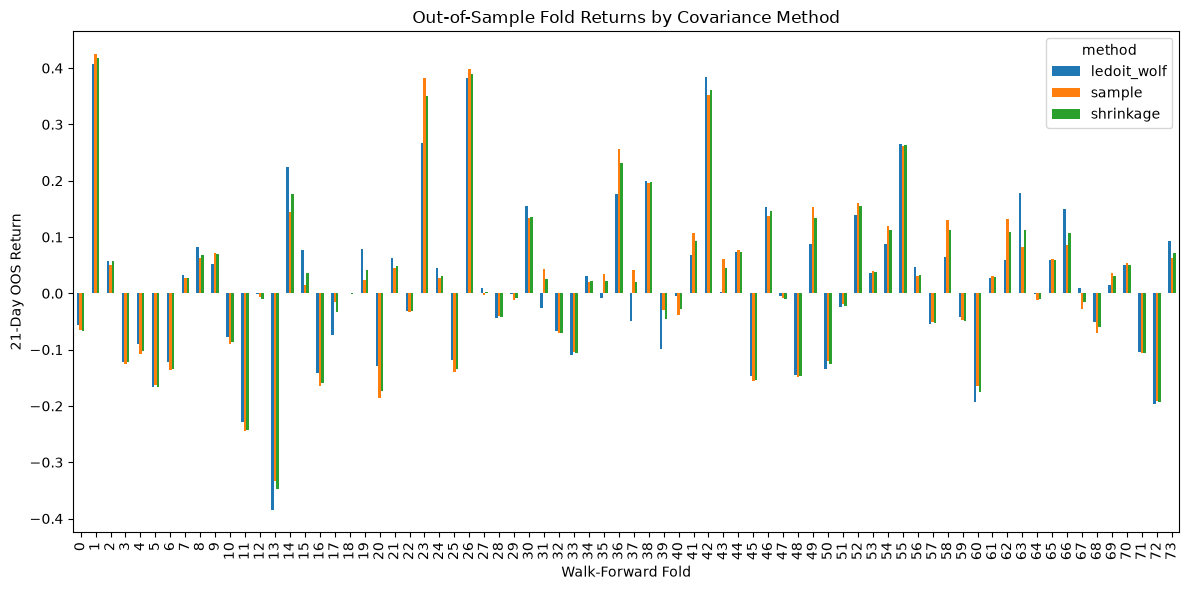

In [22]:
# Visualize the 74 OOS periods in order to determine if:
# one method consistently dominates;
# whether the methods switch leadership across periods;
# whether extreme positive/negative periods explain the aggregate result.

ax = fold_pivot.plot(
    figsize=(12, 6),
    kind="bar",
)

ax.set_title(
    "Out-of-Sample Fold Returns by Covariance Method"
)

ax.set_xlabel("Walk-Forward Fold")
ax.set_ylabel("21-Day OOS Return")

plt.tight_layout()
plt.show()

## Interpretation of Fold-Level Returns

The fold-level return plot shows that the three covariance
methodologies frequently produce similar OOS returns, while
meaningful differences appear during some walk-forward periods.

This indicates that covariance methodology does not affect portfolio
performance uniformly through time.

However, the current evidence is descriptive. The analysis does not
yet establish whether these differences are statistically significant
or whether they persist under alternative research specifications.

The next stage therefore investigates robustness to changes in
training-window length, test-window length, shrinkage intensity, and
implementation costs.

In [23]:
# Measure pairwise fold wins

pairwise = pd.DataFrame(
    {
        "sample_vs_shrinkage": (
            fold_pivot["sample"]
            > fold_pivot["shrinkage"]
        ),
        "sample_vs_ledoit_wolf": (
            fold_pivot["sample"]
            > fold_pivot["ledoit_wolf"]
        ),
        "shrinkage_vs_ledoit_wolf": (
            fold_pivot["shrinkage"]
            > fold_pivot["ledoit_wolf"]
        ),
    }
)

pairwise.mean()


sample_vs_shrinkage         0.513514
sample_vs_ledoit_wolf       0.432432
shrinkage_vs_ledoit_wolf    0.405405
dtype: float64

## Pairwise Fold Comparison

The pairwise fold comparison provides an important qualification to
the aggregate results.

Sample covariance beats shrinkage in approximately 51% of the
walk-forward folds. However, Sample covariance beats Ledoit-Wolf in
only approximately 43% of folds.

Therefore, the higher cumulative return observed for Sample covariance
does not imply that it wins the majority of individual test periods.

This distinction is important because cumulative performance depends
not only on the frequency of winning periods but also on the magnitude
and sequence of returns.

The fold-level evidence therefore suggests that the aggregate
performance differences are not simply the result of persistent
dominance in every test period.

### Pairwise Fold Win Rates

| Comparison | Proportion of folds won |
|---|---:|
| Sample vs Shrinkage | 51.35% |
| Sample vs Ledoit-Wolf | 43.24% |
| Shrinkage vs Ledoit-Wolf | 40.54% |

These comparisons are descriptive and do not constitute statistical
tests of performance superiority.

## Implementation-Cost Observation

The baseline experiment does not incorporate transaction costs because
no transaction-cost model was supplied.

Consequently, the reported returns represent gross portfolio
performance.

This is appropriate for establishing the baseline covariance
comparison, but it prevents an assessment of whether differences in
turnover translate into economically meaningful differences in
net performance.

This limitation is particularly relevant because the covariance
methods exhibit different turnover characteristics.

A subsequent research stage will introduce explicit transaction-cost
assumptions and evaluate whether the relative performance ranking
survives after implementation costs.

## Baseline Limitations

The baseline experiment provides useful descriptive evidence but does
not by itself establish a preferred covariance estimator.

Several limitations remain:

1. The experiment uses a three-asset cryptocurrency universe.

2. The baseline uses a single training-window specification.

3. The shrinkage methodology uses a fixed shrinkage intensity of
   λ = 0.25.

4. The baseline does not yet incorporate transaction costs.

5. Aggregate performance differences have not yet been subjected to
   formal statistical inference.

6. The research period represents one historical sample and may
   contain market regimes that are not representative of future
   conditions.

These limitations motivate the robustness and statistical analysis
that follows in subsequent stages of the research.

## Preliminary Research Conclusion

The baseline experiment does not provide sufficient evidence to
declare a universally superior covariance estimator.

Sample covariance currently provides the strongest aggregate return
and risk-adjusted performance.

Shrinkage provides a potentially attractive implementation trade-off
through lower average turnover and slightly lower volatility.

Ledoit-Wolf provides the smallest observed maximum drawdown and the
highest hit rate, but produces lower aggregate return and
risk-adjusted performance.

Importantly, the fold-level results weaken the interpretation of
Sample covariance as a consistently dominant methodology. Sample
covariance beats shrinkage in approximately 51% of folds and
Ledoit-Wolf in approximately 43% of folds.

Therefore, the baseline evidence should be interpreted as evidence
of different performance profiles rather than proof of estimator
superiority.

No final investment recommendation is made at this stage.

## Research Decision — Pending Further Evidence

At the baseline stage, the evidence does not justify selecting a
single covariance estimator for production portfolio construction.

The current research position is therefore:

> **No estimator is declared the definitive winner at the baseline
> stage.**

The next stage will test whether the observed differences remain
stable under alternative research specifications.

The robustness analysis will examine:

- alternative covariance-estimation training windows;
- alternative test-window lengths;
- alternative shrinkage intensities;
- implementation costs;
- and the stability of the resulting portfolio conclusions.

Only after these analyses, followed by statistical inference and
economic significance testing, will a final research recommendation
be made.

## Next Research Stage

The research will proceed through the following sequence:

**Baseline Evidence**
→ **Robustness Analysis**
→ **Statistical Inference**
→ **Economic Significance**
→ **Investment Recommendation**

The baseline establishes the reference specification against which
all subsequent sensitivity analyses will be evaluated.

The baseline parameters will remain fixed and will not be modified in
response to observed results.

# 5B — Robustness Analysis

## 5B.1 Training-Window Sensitivity

### Why test the training window?

The covariance matrix is estimated from historical returns.
Its reliability may depend on how much historical information
is used in the estimation.

The baseline analysis in Section 5A used a fixed estimation
window. We now test whether the conclusions remain stable when
the training window is changed.

We evaluate three training-window lengths:

- 126 observations
- 252 observations
- 504 observations

The test horizon, covariance methodologies, portfolio construction
method, and shrinkage intensity are held constant.

Only the training-window length changes.

### Research Question

Does the relative performance of the covariance estimators remain
stable when the estimation-window length changes?

### Hypothesis

If the baseline conclusion is robust, reasonable changes in the
training window should not completely reverse the relative ranking
of the covariance methodologies.

If rankings change substantially, the evidence would indicate that
the covariance comparison is sensitive to the amount of historical
data used for estimation.

In [24]:
from crypto_alpha_lab.research.covariance_robustness import (
    RobustnessConfiguration,
    run_covariance_robustness,
)

In [1]:
from crypto_alpha_lab.data import load_prices
import pandas as pd

assets = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
}

close_prices = pd.concat(
    {
        name: load_prices(
            ticker=ticker,
            start="2021-01-01",
            end="2025-12-31",
            refresh=True,
        )["Close"]
        for name, ticker in assets.items()
    },
    axis=1,
).dropna()

close_prices.head()

,BTC,ETH,SOL
Date,,,
2021-01-01,29374.152344,730.367554,1.842084
2021-01-02,32127.267578,774.534973,1.799275
2021-01-03,32782.023438,975.507690,2.161752
2021-01-04,31971.914062,1040.233032,2.485097
2021-01-05,33992.429688,1100.006104,2.157217


In [ ]:
print("Shape:", close_prices.shape)
print("Start:", close_prices.index.min())
print("End:", close_prices.index.max())
print("Assets:", close_prices.columns.tolist())

In [ ]:
configurations = [
    RobustnessConfiguration(
        train_size=126,
        test_size=21,
        shrinkage=0.25,
    ),
    RobustnessConfiguration(
        train_size=252,
        test_size=21,
        shrinkage=0.25,
    ),
    RobustnessConfiguration(
        train_size=504,
        test_size=21,
        shrinkage=0.25,
    ),
]

### Experimental control

The test window is fixed at 21 observations across all
configurations.

The shrinkage intensity is fixed at 0.25 wherever explicit
shrinkage is used.

Therefore, the only experimental dimension being changed is
the covariance-estimation training window.

In [ ]:
robustness_result = run_covariance_robustness(
    prices=close_prices,
    configurations=configurations,
)

In [ ]:
robustness_result.metadata

In [ ]:
robustness_result.summary

In [ ]:
robustness_result.summary[
    [
        "method",
        "train_size",
        "test_size",
        "total_return",
        "observation_count",
        "fold_count",
    ]
]

In [ ]:
robustness_result.summary.sort_values(
    [
        "train_size",
        "total_return",
    ],
    ascending=[
        True,
        False,
    ],
)

### Results

The robustness experiment produces nine strictly out-of-sample
experiments: three covariance methodologies evaluated under each
of the three training-window configurations.

We first examine total return to determine whether the relative
performance of the covariance methodologies changes as the
estimation window changes.

The purpose is not to identify the single highest-return
configuration, but to determine whether the conclusions from the
baseline analysis remain reasonably stable under alternative
training-window choices.

### Interpretation

The training-window sensitivity analysis produces a stable
performance ranking across all three estimation-window choices.

Sample covariance achieves the highest total return under all
configurations, followed by the explicit shrinkage estimator and
then the Ledoit–Wolf estimator.

The ranking is therefore:

Sample > Shrinkage > Ledoit–Wolf

for 126, 252, and 504 training observations.

This consistency supports the robustness of the baseline conclusion
to the choice of covariance-estimation window.

However, the magnitude of performance varies substantially with
the training window. Sample covariance increases from 82.25% under
the 126-observation configuration to 194.90% under the
504-observation configuration.

Therefore, the evidence suggests that the estimation-window choice
affects absolute portfolio performance, while the relative ranking
of the covariance methodologies remains stable.

The number of out-of-sample observations also decreases as the
training window becomes longer. Consequently, differences in total
return should not be interpreted as being caused exclusively by
the training-window length. The analysis is best interpreted as a
sensitivity test of the overall research conclusion rather than as
a controlled causal estimate of training-window effects.

But our robustness summary results above only deals with contains:
method
train_size
test_size
shrinkage
total_return
observation_count
fold_count

But we can derive even richer metrics directly from the existing experiments.

In [ ]:
from crypto_alpha_lab.evaluation.covariance_comparison import (
    compare_covariance_methods,
)

robustness_evaluations = []

for configuration in configurations:

    matching = [
        experiment
        for experiment in robustness_result.experiments
        if experiment.parameters["train_size"]
        == configuration.train_size
    ]

    comparison = compare_covariance_methods(
        matching,
        periods_per_year=365,
        risk_free_rate=0.0,
    )

    table = comparison.summary.copy()

    table["train_size"] = configuration.train_size

    robustness_evaluations.append(
        table.reset_index()
    )

robustness_metrics = pd.concat(
    robustness_evaluations,
    ignore_index=True,
)

robustness_metrics

In [ ]:
robustness_metrics[
    [
        "train_size",
        "method",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "sortino_ratio",
        "maximum_drawdown",
        "calmar_ratio",
        "hit_rate",
        "average_turnover",
    ]
].sort_values(
    ["train_size", "sharpe_ratio"],
    ascending=[True, False],
)

## Training-Window Sensitivity: Evidence
The important result is that Sample covariance remains the highest-Sharpe methodology at every training-window length:

| Training window |    Sample | Shrinkage | Ledoit–Wolf | Ranking                 |
| --------------: | --------: | --------: | ----------: | ----------------------- |
|             126 | **0.514** |     0.476 |       0.351 | Sample > Shrinkage > LW |
|             252 | **0.542** |     0.521 |       0.464 | Sample > Shrinkage > LW |
|             504 | **0.862** |     0.824 |       0.713 | Sample > Shrinkage > LW |


1. Relative performance is remarkably stable

Across all three estimation windows, we get:

Sample > Shrinkage > Ledoit–Wolf

for:

total return
annualized return
Sharpe ratio
Sortino ratio
Calmar ratio

That is considerably stronger evidence than merely observing the same total-return ranking.

2. The risk picture is more nuanced

At 126 observations:

Sample volatility: 56.30%
Shrinkage: 56.26%
Ledoit–Wolf: 56.59%

At 252:

Sample: 52.55%
Shrinkage: 52.40%
Ledoit–Wolf: 52.59%

At 504:

Sample: 49.23%
Shrinkage: 49.14%
Ledoit–Wolf: 49.61%

So the methods have very similar volatility.

**Drawdown tells an interesting story**

At the longest window:
| Method      | Max drawdown |
| ----------- | -----------: |
| Sample      |      -52.16% |
| Shrinkage   |      -49.87% |
| Ledoit–Wolf |  **-45.19%** |


This means Ledoit–Wolf produces the least severe drawdown, despite having the lowest return and Sharpe ratio.

That is important.

We should not conclude:

"Sample covariance is universally superior."

A better research conclusion is:

Sample covariance produced the strongest return and risk-adjusted performance, while Ledoit–Wolf provided comparatively better drawdown characteristics.

Turnover reveals another trade-off

The pattern is:

| Training | Sample | Shrinkage | Ledoit–Wolf |
| -------: | -----: | --------: | ----------: |
|      126 |  1.211 | **1.102** |       1.336 |
|      252 |  1.219 | **1.111** |       1.352 |
|      504 |  1.234 | **1.132** |       1.382 |


Shrinkage consistently has the lowest turnover.

Ledoit–Wolf consistently has the highest turnover.

So we now have a very interesting research story:

Sample covariance maximizes observed performance, shrinkage reduces turnover while remaining close to Sample, and Ledoit–Wolf sacrifices performance in exchange for lower drawdown.

That is a much richer conclusion than simply "Sample won."

### 5B.1 Conclusion

The training-window sensitivity analysis provides evidence that the
relative performance ranking observed in the baseline experiment is
robust to reasonable changes in the covariance-estimation window.

Across 126, 252, and 504 training observations, sample covariance
consistently produces the highest total return, annualized return,
Sharpe ratio, Sortino ratio, and Calmar ratio. The ranking remains:

Sample > Shrinkage > Ledoit–Wolf.

The stability of this ranking strengthens the baseline conclusion
because it does not depend on a single estimation-window choice.

However, the results also reveal important trade-offs. Shrinkage
consistently produces lower portfolio turnover than sample covariance,
while Ledoit–Wolf produces the lowest maximum drawdown across all
three configurations. Thus, sample covariance should not be viewed
as universally superior across every investment objective.

The results suggest that covariance methodology involves a
performance-risk-implementation trade-off: sample covariance has
the strongest observed risk-adjusted performance, shrinkage offers
lower turnover with relatively competitive performance, and
Ledoit–Wolf provides comparatively lower drawdown at the cost of
lower return and risk-adjusted performance.

The analysis should nevertheless be interpreted as a sensitivity
analysis rather than a causal estimate of training-window effects.
Longer training windows also reduce the number of available
out-of-sample observations, so differences in aggregate performance
cannot be attributed exclusively to the estimation-window length.

### Training-Window Sensitivity of Sharpe Ratio

The following comparison shows whether the relative risk-adjusted
performance of the covariance methodologies changes as the
estimation window increases.

In [ ]:
import matplotlib.pyplot as plt

sharpe_pivot = robustness_metrics.pivot(
    index="train_size",
    columns="method",
    values="sharpe_ratio",
)

ax = sharpe_pivot.plot(
    marker="o",
    figsize=(10, 6),
)

ax.set_title(
    "Sharpe Ratio Across Covariance Estimation Windows"
)
ax.set_xlabel("Training Window (observations)")
ax.set_ylabel("Sharpe Ratio")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

----------------------------------------------------

## Shrinkage-Intensity Sensitivity

### Why test shrinkage intensity?

The explicit shrinkage estimator combines the sample covariance
matrix with a structured target matrix.

The shrinkage intensity controls how strongly the estimator moves
away from the sample covariance toward the target.

Our baseline analysis used a shrinkage intensity of 0.25.

We therefore test whether the empirical conclusion is sensitive
to this particular parameter choice.

### Research Question

Does the performance of the shrinkage covariance estimator remain
competitive across reasonable shrinkage-intensity choices?

### Hypothesis

If the baseline result is robust, changing the shrinkage intensity
within a reasonable range should not completely alter the relative
performance conclusion.

Large changes in performance or ranking would indicate sensitivity
to the shrinkage parameter.

## Experimental Design

We hold the following constant:

| Parameter           | Setting                 |
| ------------------- | ----------------------- |
| Training window     | 252 observations        |
| Test window         | 21 observations         |
| Portfolio           | Global Minimum Variance |
| Validation          | Walk-forward            |
| Sample covariance   | Fixed                   |
| Ledoit–Wolf         | Fixed                   |
| Shrinkage intensity | **Varied**              |

We'll test at varied shrinkage levels: \
0.00 \
0.10 \
0.25 \
0.50 \
0.75 \
1.00 

There is a useful conceptual reason for including the endpoints:

0.00 approaches the sample covariance. \
0.25 is our baseline. \
0.50 represents substantial shrinkage. \
0.75 represents strong shrinkage. \
1.00 represents full shrinkage toward the target.

This gives us a meaningful sensitivity curve rather than testing only two arbitrary values.

In [ ]:
shrinkage_levels = [
    0.00,
    0.10,
    0.25,
    0.50,
    0.75,
    1.00,
]

shrinkage_configurations = [
    RobustnessConfiguration(
        train_size=252,
        test_size=21,
        shrinkage=level,
    )
    for level in shrinkage_levels
]

### Experimental control

The training window is fixed at 252 observations and the test
window at 21 observations.

Only the explicit shrinkage intensity changes.

This isolates parameter sensitivity from the training-window
sensitivity examined in Section 5B.1.

In [ ]:
shrinkage_robustness = run_covariance_robustness(
    prices=close_prices,
    configurations=shrinkage_configurations,
    methods=["shrinkage"],
)

In [ ]:
shrinkage_robustness.summary

In [ ]:
# Verify the experiment

print(shrinkage_robustness.metadata)

In [ ]:
assert (
    shrinkage_robustness.metadata["out_of_sample"]
    is True
)

assert (
    shrinkage_robustness.metadata["experiment_count"]
    == 6
)

In [ ]:
shrinkage_robustness.summary.sort_values(
    "train_size"
)

In [ ]:
shrinkage_results = (
    shrinkage_robustness.summary[
        [
            "shrinkage",
            "total_return",
            "observation_count",
            "fold_count",
        ]
    ]
    .sort_values("shrinkage")
    .reset_index(drop=True)
)

shrinkage_results

In [ ]:
from crypto_alpha_lab.evaluation.performance import (
    PerformanceAnalyzer,
)

analyzer = PerformanceAnalyzer(
    periods_per_year=365,
    risk_free_rate=0.0,
)

rows = []

for experiment in shrinkage_robustness.experiments:

    report = analyzer.analyze(
        experiment.returns
    )

    rows.append(
        {
            "shrinkage": experiment.parameters[
                "shrinkage"
            ],
            "total_return": report.total_return,
            "annualized_return": report.annualized_return,
            "annualized_volatility": (
                report.annualized_volatility
            ),
            "sharpe_ratio": report.sharpe_ratio,
            "sortino_ratio": report.sortino_ratio,
            "maximum_drawdown": (
                report.maximum_drawdown
            ),
            "calmar_ratio": report.calmar_ratio,
            "hit_rate": report.hit_rate,
            "observation_count": (
                report.observation_count
            ),
        }
    )

shrinkage_metrics = (
    pd.DataFrame(rows)
    .sort_values("shrinkage")
    .reset_index(drop=True)
)

shrinkage_metrics

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    shrinkage_metrics["shrinkage"],
    shrinkage_metrics["sharpe_ratio"],
    marker="o",
)

plt.xlabel("Shrinkage Intensity")
plt.ylabel("Sharpe Ratio")
plt.title(
    "Shrinkage-Intensity Sensitivity of Sharpe Ratio"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    shrinkage_metrics["shrinkage"],
    shrinkage_metrics["total_return"],
    marker="o",
)

plt.xlabel("Shrinkage Intensity")
plt.ylabel("Total Return")
plt.title(
    "Shrinkage-Intensity Sensitivity of Total Return"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [ ]:
shrinkage_metrics

The varied shrinkage metrics gives us a very clean sensitivity result. More importantly, it reveals a useful trade-off rather than merely confirming the baseline.

Shrinkage-Intensity Sensitivity

We held the research design constant:

Training window: 252 observations\
Test window: 21 observations\
Walk-forward OOS validation\
GMV portfolio\
Same BTC/ETH/SOL dataset\
Shrinkage intensity varied from 0.00 to 1.00

1. The central finding

There is a monotonic decline in return and risk-adjusted performance as shrinkage intensity increases.\
| Shrinkage | Total Return |    Sharpe |    Sortino | Max Drawdown |
| --------: | -----------: | --------: | ---------: | -----------: |
|  **0.00** |   **86.97%** | **0.542** | **0.0417** |      -78.20% |
|      0.10 |       83.29% |     0.533 |     0.0410 |      -77.60% |
|  **0.25** |   **78.17%** | **0.521** | **0.0399** |      -76.74% |
|      0.50 |       70.50% |     0.501 |     0.0383 |      -75.37% |
|      0.75 |       63.53% |     0.482 |     0.0368 |      -74.04% |
|      1.00 |       56.88% |     0.464 |     0.0354 |  **-72.58%** |

This is a very informative result.

As shrinkage increases:

Return decreases

86.97% → 56.88%

Sharpe decreases

0.542 → 0.464

Sortino decreases

0.0417 → 0.0354

Drawdown improves

-78.20% → -72.58%

So stronger shrinkage is not free.

It reduces the magnitude of the portfolio's drawdowns, but it also progressively reduces return and risk-adjusted performance.


The baseline 0.25 is not an arbitrary winner

Our baseline value:

shrinkage = 0.25

sits in the middle of the sensitivity curve.

It produces:
|
Total return       78.17%\
Annualized return  14.53%\
Sharpe              0.521\
Sortino             0.0399\
Max drawdown       -76.74%\
Calmar              0.202

So the baseline isn't the optimal point for return or Sharpe.

But it represents a moderate compromise between no shrinkage and aggressive shrinkage.


The most interesting finding: volatility barely changes

Look at this:\
| Shrinkage level| Volatility|
|---------------:|----------:|
| 0.00 →| 52.55%
0.10 → | 52.46%
0.25 → | 52.40%
0.50 → | 52.38%
0.75 → | 52.45%
1.00 → | 52.59%

Volatility is essentially flat.

That means the deterioration in Sharpe is primarily being driven by lower returns, rather than a dramatic reduction in volatility.

This is a particularly useful research observation.

We can say:

Increasing shrinkage materially reduces portfolio returns while leaving annualized volatility broadly unchanged.

That helps explain why the Sharpe ratio declines.

**But shrinkage improves downside risk**

The drawdown progression is striking:
|Shrinkage Level| Drawdown|
|--------------:|--------:|
|0.00 |  -78.20%
|0.10 | -77.60%
|0.25 |  -76.74%
|0.50 | -75.37%
|0.75 |  -74.04%
|1.00 |  -72.58%

So there is a clear trade-off:

More shrinkage → lower return/risk-adjusted performance, but less severe maximum drawdown.

The hit rate also improves

Interestingly:
|Shrinkage Level | Hit Rate|
|---------------:|--------:|
|0.00 →| 49.36%
|1.00 → |50.84%

The hit rate increases as shrinkage increases.

Yet total return declines.

That is another useful lesson:

Win rate alone is not sufficient to evaluate a portfolio strategy.

A strategy can have a slightly higher proportion of positive observations while producing substantially lower aggregate returns.

### Interpretation

The shrinkage-intensity sensitivity analysis reveals a systematic
trade-off between return performance and downside protection.

As shrinkage intensity increases from 0.00 to 1.00, total return,
annualized return, Sharpe ratio, Sortino ratio, and Calmar ratio
decline progressively.

The baseline shrinkage intensity of 0.25 therefore does not represent
the return-maximizing or Sharpe-maximizing specification. Instead, it
represents a moderate level of shrinkage between the sample-like
0.00 specification and the fully shrunk 1.00 specification.

At the same time, stronger shrinkage progressively improves maximum
drawdown, from -78.20% at zero shrinkage to -72.58% at full
shrinkage.

Annualized volatility remains remarkably stable across the entire
parameter range, varying only from approximately 52.38% to 52.59%.
Therefore, the deterioration in Sharpe ratio as shrinkage increases
is primarily associated with lower returns rather than a major
change in volatility.

The results indicate that shrinkage intensity introduces a
performance-risk trade-off rather than a universally optimal
parameter. Lower shrinkage produces stronger observed return and
risk-adjusted performance, while higher shrinkage provides somewhat
better downside protection.

The results also demonstrate why portfolio evaluation should not
depend on hit rate alone. Hit rate increases modestly with stronger
shrinkage, while total return and risk-adjusted performance decline.

### 5B.2 Conclusion

The shrinkage-intensity analysis shows that the baseline conclusion
is sensitive to the degree of shrinkage applied.

Higher shrinkage consistently reduces observed return and
risk-adjusted performance while improving maximum drawdown.
However, annualized volatility remains broadly unchanged.

The baseline intensity of 0.25 therefore represents a moderate
trade-off rather than an empirically dominant parameter.

This finding qualifies the baseline covariance comparison:
shrinkage can improve certain risk characteristics, but stronger
shrinkage does not improve the overall return or Sharpe performance
of the tested GMV portfolio in this sample.

Consequently, the appropriate shrinkage intensity should be viewed
as an investment-design choice rather than a universally optimal
value.

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    shrinkage_metrics["shrinkage"],
    shrinkage_metrics["sharpe_ratio"],
    marker="o",
)

plt.xlabel("Shrinkage Intensity")
plt.ylabel("Sharpe Ratio")
plt.title(
    "Sharpe Ratio Sensitivity to Shrinkage Intensity"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    shrinkage_metrics["shrinkage"],
    shrinkage_metrics["maximum_drawdown"],
    marker="o",
)

plt.xlabel("Shrinkage Intensity")
plt.ylabel("Maximum Drawdown")
plt.title(
    "Maximum Drawdown Sensitivity to Shrinkage Intensity"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

 The two graphs above show the trade off between 
 Maximum Drawdown Sensitivity to shrinkage intensity and sharpe ratio sensitivity to shrikage intensity.

 As shrinkage intensifies, maximum drawdown increases, while sharpe ratio declines. 

Where this leaves our research

We now have two independent robustness dimensions:

— Training-window sensitivity

Result:
The ranking remained:

Sample > Shrinkage > Ledoit–Wolf

across 126, 252 and 504 observations.

— Shrinkage-intensity sensitivity

Result:
Increasing shrinkage produced a systematic:

performance ↔ downside-risk trade-off

----------------------------------------------



# Robustness Synthesis

Our next objective is to synthesize the evidence we've already generated.

We'll answer:

Across the baseline, training-window sensitivity, and shrinkage-intensity sensitivity analyses, how strong is the overall evidence for our covariance-method conclusion?

We'll build a compact evidence matrix covering:

performance ranking;
Sharpe;
drawdown;
turnover;
training-window stability;
shrinkage sensitivity.



### Objective

The previous sections examined two sources of specification
uncertainty:

1. the length of the covariance-estimation training window; and
2. the intensity of explicit covariance shrinkage.

This section synthesizes those findings into a single evidence
framework.

The purpose is not to identify a universally optimal covariance
estimator. Instead, we assess how stable the baseline conclusions
are and identify the trade-offs that remain relevant for portfolio
construction.

In [ ]:
# Create Evidence Metrics
robustness_evidence = pd.DataFrame(
    {
        "Evidence Dimension": [
            "Training-window ranking",
            "Total-return performance",
            "Risk-adjusted performance",
            "Maximum drawdown",
            "Turnover",
            "Shrinkage-parameter sensitivity",
            "Overall conclusion",
        ],
        "Finding": [
            "Sample > Shrinkage > Ledoit-Wolf across 126, 252, and 504 observations.",
            "Sample covariance produced the highest observed return across the tested training windows.",
            "Sample covariance produced the highest Sharpe, Sortino, and Calmar ratios across the tested training windows.",
            "Ledoit-Wolf produced the least severe maximum drawdown.",
            "Explicit shrinkage produced the lowest turnover in the baseline and training-window analyses.",
            "Higher shrinkage reduced return and risk-adjusted performance but improved maximum drawdown.",
            "The baseline ranking is robust to training-window choice, but covariance methodology involves meaningful performance-risk-implementation trade-offs.",
        ],
    }
)

robustness_evidence

In [ ]:
# Quantify Ranking Stability
# We should make the training-window result explicit rather than merely describing it.

training_window_rankings = (
    robustness_metrics
    .sort_values(
        [
            "train_size",
            "sharpe_ratio",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby("train_size")["method"]
    .apply(list)
)

training_window_rankings

In [ ]:
# Then calculate the proportion of configurations in which each method is ranked first.
winner_counts = (
    robustness_metrics
    .sort_values(
        [
            "train_size",
            "sharpe_ratio",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby("train_size")
    .first()["method"]
    .value_counts()
)

winner_share = (
    winner_counts
    / winner_counts.sum()
)

winner_share

Sample covariance ranked first in 100% of the tested training-window configurations when Sharpe ratio is used as the ranking criterion.

In [ ]:
# Let's determine where our baseline shrinkage of 0.25 sits in the parameter sensitivity experiment.

baseline_shrinkage = shrinkage_metrics.loc[
    shrinkage_metrics["shrinkage"] == 0.25
].iloc[0]

baseline_shrinkage

In [ ]:
# Then calculate its distance from the best and worst Sharpe configurations in the shrinkage sensitivity experiment.

best_shrinkage_sharpe = (
    shrinkage_metrics["sharpe_ratio"].max()
)

worst_shrinkage_sharpe = (
    shrinkage_metrics["sharpe_ratio"].min()
)

baseline_sharpe = (
    baseline_shrinkage["sharpe_ratio"]
)

print(
    "Baseline Sharpe:",
    baseline_sharpe,
)

print(
    "Best Sharpe:",
    best_shrinkage_sharpe,
)

print(
    "Worst Sharpe:",
    worst_shrinkage_sharpe,
)

From the results above, we can see that our baseline shrinkage of 0.25 produces a Sharpe ratio of 0.5207. Best Sharpe is 0.5422, while worst Sharpe is 0.4640 sits in between best Sharpe. This shows that our baseline lies between best Sharpe and worst Sharpe ratios.

In [ ]:
# Create the Robustness Summary Table
robustness_summary = pd.DataFrame(
    {
        "Analysis": [
            "Baseline covariance comparison",
            "Training-window sensitivity",
            "Shrinkage-intensity sensitivity",
        ],
        "Design": [
            "252-observation training window",
            "126 / 252 / 504 observations",
            "0.00 / 0.10 / 0.25 / 0.50 / 0.75 / 1.00",
        ],
        "Primary Finding": [
            "Sample covariance had the strongest overall observed performance.",
            "Performance ranking remained Sample > Shrinkage > Ledoit-Wolf.",
            "Higher shrinkage reduced return and Sharpe while improving drawdown.",
        ],
        "Interpretation": [
            "Baseline evidence favors sample covariance for this GMV specification.",
            "Baseline ranking is robust to training-window choice.",
            "Shrinkage intensity represents a performance-risk trade-off rather than a universally optimal parameter.",
        ],
    }
)

robustness_summary

### Robustness Synthesis

Taken together, the robustness analyses provide meaningful support
for the baseline covariance comparison.

First, the relative ranking of the covariance methodologies remains
stable when the training window is changed from 126 to 252 and 504
observations. Sample covariance consistently produces the strongest
observed return and risk-adjusted performance, followed by explicit
shrinkage and Ledoit-Wolf covariance.

Second, the shrinkage-intensity analysis shows that the performance
of the explicit shrinkage estimator is parameter-sensitive. As
shrinkage intensity increases, return and risk-adjusted performance
decline progressively, while maximum drawdown improves.

The evidence therefore supports the baseline finding without
suggesting that sample covariance is universally optimal. Instead,
the results indicate a trade-off between return, risk-adjusted
performance, downside protection, and portfolio implementation
characteristics.

For the tested BTC, ETH, and SOL GMV portfolio, sample covariance
provides the strongest observed risk-adjusted performance across
the tested training windows. Explicit shrinkage provides lower
turnover and somewhat better drawdown characteristics, while
Ledoit-Wolf provides the strongest drawdown protection among the
three covariance methodologies but lower observed return and
risk-adjusted performance.

Overall, the baseline ranking appears robust to the tested
training-window specifications, while the choice of shrinkage
intensity materially affects the trade-off between performance and
downside risk.

### Robustness Limitations

The robustness analysis does not establish that one covariance
methodology is universally superior.

The experiments are conducted on a specific three-asset universe
(BTC, ETH, and SOL), using a global minimum-variance portfolio and
a particular walk-forward design.

The training-window sensitivity analysis also changes the number
of available out-of-sample observations. Longer training windows
leave fewer observations available for subsequent evaluation.

In addition, the shrinkage-intensity analysis evaluates a finite
set of parameter values rather than the full parameter space.

The conclusions should therefore be interpreted as evidence about
the robustness of the tested research specification, not as a
universal statement about covariance estimation in all markets or
portfolio constructions.

## Robustness Verdict

### Evidence supports the baseline conclusion, with important qualifications.

The covariance-method ranking remains stable across the tested
training windows, providing evidence that the baseline result is
not driven solely by the choice of estimation-window length.

However, shrinkage sensitivity demonstrates that covariance
estimation involves a meaningful trade-off between return,
risk-adjusted performance, and downside protection.

The appropriate covariance specification therefore depends on the
portfolio objective rather than on a universally dominant estimator.

-------------------------------------------------------------------

### Research Validation & Evidence Package

## Objective

This section converts the empirical results from the baseline and
robustness analyses into a formal research evidence package.

The objective is to distinguish:

1. what the experiments directly demonstrate;
2. what conclusions are supported by the evidence;
3. what remains uncertain; and
4. what limitations constrain interpretation.

The analysis therefore moves from:

    Results → Evidence → Claim → Qualification

rather than treating observed performance as proof of universal
superiority.

## Research Question

> How sensitive is the out-of-sample performance of a global
> minimum-variance cryptocurrency portfolio to the choice of
> covariance estimator and its key estimation parameters?

### Sub-questions

1. Does covariance methodology affect portfolio performance?
2. Does the relative ranking of covariance estimators remain stable
   across different training-window lengths?
3. How does explicit shrinkage intensity affect performance and risk?
4. Are there meaningful trade-offs between return, risk-adjusted
   performance, drawdown, and turnover?
5. Which conclusions are sufficiently robust to support a research
   recommendation?

## Evidence Hierarchy

The strength of each conclusion is assessed according to the following
hierarchy:

### Level 1 — Direct observation

A numerical result directly produced by the experiment.

Example:

> Sample covariance produced a Sharpe ratio of 0.542 in the
> 252-observation baseline experiment.

### Level 2 — Repeated evidence

The same relationship appears across multiple experimental
configurations.

Example:

> Sample covariance ranked ahead of shrinkage and Ledoit-Wolf across
> the 126-, 252-, and 504-observation training windows.

### Level 3 — Robust research conclusion

A finding that survives the tested specification changes and remains
consistent with the research objective.

Example:

> The relative performance ranking is robust to the tested
> training-window specifications.

### Level 4 — Unsupported generalization

A statement that extends beyond the tested universe, methodology,
period, or portfolio construction.

Example:

> Sample covariance is universally superior to shrinkage estimators.

Such claims are explicitly excluded from the conclusions.

In [ ]:
# Now we produce the evidence matrix

evidence_matrix = pd.DataFrame(
    [
        {
            "claim": (
                "Covariance methodology materially affects "
                "portfolio performance."
            ),
            "evidence": (
                "Baseline comparison shows different total returns, "
                "Sharpe ratios, drawdowns, and turnover across "
                "sample, shrinkage, and Ledoit-Wolf methods."
            ),
            "robustness": (
                "Observed across multiple training-window "
                "configurations."
            ),
            "strength": "Strong",
        },
        {
            "claim": (
                "Sample covariance produced the strongest observed "
                "risk-adjusted performance."
            ),
            "evidence": (
                "Sample covariance produced the highest Sharpe, "
                "Sortino, and Calmar ratios in the tested "
                "training-window configurations."
            ),
            "robustness": (
                "Sample ranked first across 126, 252, and "
                "504 observations."
            ),
            "strength": "Strong",
        },
        {
            "claim": (
                "The covariance-method ranking is robust to "
                "training-window choice."
            ),
            "evidence": (
                "The ranking remained Sample > Shrinkage > "
                "Ledoit-Wolf across all three training windows."
            ),
            "robustness": (
                "Confirmed across 126-, 252-, and "
                "504-observation windows."
            ),
            "strength": "Strong",
        },
        {
            "claim": (
                "Shrinkage intensity creates a performance-risk "
                "trade-off."
            ),
            "evidence": (
                "Increasing shrinkage reduced return and "
                "risk-adjusted performance while improving "
                "maximum drawdown."
            ),
            "robustness": (
                "Observed across six tested shrinkage intensities."
            ),
            "strength": "Strong",
        },
        {
            "claim": (
                "Shrinkage can improve implementation characteristics."
            ),
            "evidence": (
                "Explicit shrinkage produced lower turnover than "
                "sample covariance in the baseline and training-"
                "window analyses."
            ),
            "robustness": (
                "The turnover advantage remained visible across "
                "tested training windows."
            ),
            "strength": "Moderate",
        },
        {
            "claim": (
                "One covariance estimator is universally superior."
            ),
            "evidence": (
                "The experiments do not test enough markets, "
                "portfolio constructions, or regimes to support "
                "this claim."
            ),
            "robustness": (
                "Not established."
            ),
            "strength": "Unsupported",
        },
    ]
)

evidence_matrix

In [ ]:
# Make the Evidence Quantitative

# Now let's make the strongest claims measurable.

## Training-window robustness

training_window_evidence = (
    robustness_metrics[
        [
            "train_size",
            "method",
            "sharpe_ratio",
            "sortino_ratio",
            "calmar_ratio",
            "maximum_drawdown",
            "average_turnover",
        ]
    ]
    .sort_values(
        [
            "train_size",
            "sharpe_ratio",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

training_window_evidence

In [ ]:
# Calculate Ranking Stability

ranking_table = (
    robustness_metrics
    .assign(
        sharpe_rank=(
            robustness_metrics
            .groupby("train_size")[
                "sharpe_ratio"
            ]
            .rank(
                ascending=False,
                method="min",
            )
        )
    )
    [
        [
            "train_size",
            "method",
            "sharpe_ratio",
            "sharpe_rank",
        ]
    ]
    .sort_values(
        [
            "train_size",
            "sharpe_rank",
        ]
    )
)

ranking_table

In [ ]:
sample_first_rate = (
    (
        ranking_table[
            ranking_table["sharpe_rank"] == 1
        ]["method"]
        == "sample"
    )
    .mean()
)

print(
    f"Sample covariance first-place rate: "
    f"{sample_first_rate:.1%}"
)

Sample covariance ranked first by Sharpe ratio in 100% of the tested training-window configurations.

In [ ]:
# Quantify the Shrinkage Trade-off
# We already have the six shrinkage experiments.
# Let's explicitly measure the change from zero to full shrinkage.

no_shrinkage = (
    shrinkage_metrics
    .loc[
        shrinkage_metrics["shrinkage"] == 0.00
    ]
    .iloc[0]
)

full_shrinkage = (
    shrinkage_metrics
    .loc[
        shrinkage_metrics["shrinkage"] == 1.00
    ]
    .iloc[0]
)

shrinkage_tradeoff = pd.Series(
    {
        "change_in_total_return": (
            full_shrinkage["total_return"]
            - no_shrinkage["total_return"]
        ),
        "change_in_annualized_return": (
            full_shrinkage["annualized_return"]
            - no_shrinkage["annualized_return"]
        ),
        "change_in_sharpe": (
            full_shrinkage["sharpe_ratio"]
            - no_shrinkage["sharpe_ratio"]
        ),
        "change_in_maximum_drawdown": (
            full_shrinkage["maximum_drawdown"]
            - no_shrinkage["maximum_drawdown"]
        ),
    }
)

shrinkage_tradeoff

## Baseline Decision

The baseline experiment used a 252-observation training window and
0.25 explicit shrinkage intensity.

The evidence does not justify replacing the baseline specification
simply because another configuration produced a higher historical
return.

Instead, the robustness analysis provides a decision framework:

- Sample covariance provides the strongest observed performance and
  risk-adjusted metrics in the tested configurations.
- Explicit shrinkage reduces turnover and improves drawdown
  characteristics relative to the sample estimator.
- Increasing shrinkage beyond the baseline progressively reduces
  observed return and risk-adjusted performance.
- Ledoit-Wolf provides comparatively stronger downside protection
  than the other methods but lower observed performance in this
  experiment.

Therefore, the research conclusion is not:

> "Sample covariance is always best."

It is:

> "Under the tested three-asset GMV specification, sample covariance
> produced the strongest observed risk-adjusted performance, while
> shrinkage-based approaches offered alternative risk and
> implementation characteristics."

## Research Limitations

Several limitations constrain the interpretation of the findings.

### 1. Asset universe

The analysis uses BTC, ETH, and SOL. The results may not generalize
to larger cryptocurrency universes or traditional asset classes.

### 2. Portfolio construction

The experiments use a global minimum-variance portfolio. Different
portfolio objectives may produce different conclusions.

### 3. Historical sample

The conclusions are conditional on the historical period contained
in the dataset and may not hold under materially different market
regimes.

### 4. Parameter grid

The shrinkage analysis evaluates six discrete shrinkage intensities.
It does not establish an optimal continuous parameter.

### 5. Transaction-cost assumptions

The robustness experiments report turnover and transaction costs,
but the conclusions remain conditional on the transaction-cost model
used by the backtest.

### 6. Model scope

The research evaluates covariance estimation rather than the full
investment decision process. Expected-return estimation, alternative
portfolio constraints, leverage, liquidity, and regime-dependent
allocation are outside the scope of this experiment.

### 7. Multiple testing

The robustness analysis examines several configurations. The results
should therefore be interpreted as sensitivity evidence rather than
as confirmation that the best-performing configuration was selected
without any specification search.

# Research Validation Verdict

## What the evidence supports

The experiments provide evidence that covariance estimation materially
affects the performance and implementation characteristics of a
global minimum-variance cryptocurrency portfolio.

Across the tested training windows, sample covariance consistently
produced the strongest observed risk-adjusted performance.

The relative ranking of the three covariance methodologies remained
stable across the 126-, 252-, and 504-observation training windows,
providing evidence that the baseline ranking is not solely driven by
one particular training-window specification.

The shrinkage-intensity analysis, however, demonstrates an important
trade-off. Increasing shrinkage progressively reduced return and
risk-adjusted performance while improving maximum drawdown.

Consequently, covariance estimation should not be viewed as a simple
winner-takes-all problem. The preferred estimator depends on the
research objective and the relative importance assigned to return,
risk-adjusted performance, drawdown, and portfolio turnover.

## Final conclusion

For the tested BTC/ETH/SOL global minimum-variance portfolio,
sample covariance provides the strongest observed risk-adjusted
performance across the tested specifications.

However, the evidence does not establish universal superiority.
Shrinkage methods provide meaningful alternative characteristics,
particularly in terms of drawdown and turnover.

The appropriate research conclusion is therefore conditional:

> Sample covariance is the strongest-performing estimator under the
> tested specification, while shrinkage provides a defensible
> alternative when greater emphasis is placed on downside protection
> or implementation stability.

This conclusion remains subject to the asset universe, historical
period, portfolio construction method, transaction-cost assumptions,
and parameter grid examined in the study.

----------------------------------------------------

---

# Research Evidence Card

### Research question
How sensitive is GMV portfolio performance to covariance-estimation
methodology and specification?

### Methods tested
- Sample covariance
- Explicit shrinkage
- Ledoit-Wolf shrinkage

### Validation design
Strictly out-of-sample walk-forward evaluation.

### Robustness tests
- 126-observation training window
- 252-observation training window
- 504-observation training window
- Shrinkage intensity: 0.00–1.00

### Main empirical finding
Sample covariance ranked first by Sharpe ratio across all tested
training-window configurations.

### Important trade-off
Higher shrinkage reduced return and risk-adjusted performance while
improving maximum drawdown.

### Implementation insight
Explicit shrinkage generally produced lower turnover than sample
covariance.

### Research conclusion
Sample covariance produced the strongest observed risk-adjusted
performance under the tested GMV specification, but shrinkage
provides meaningful alternatives when downside protection or
implementation characteristics receive greater weight.

### Key limitation
The findings are conditional on the tested cryptocurrency universe,
historical period, portfolio construction, and experimental design.

In [ ]:
# Final Verdict Table
research_validation = pd.DataFrame(
    {
        "Dimension": [
            "Research question",
            "Out-of-sample design",
            "Covariance methods",
            "Training-window sensitivity",
            "Shrinkage sensitivity",
            "Performance leader",
            "Drawdown leader",
            "Turnover consideration",
            "Generalization",
        ],
        "Result": [
            "Covariance methodology affects GMV portfolio outcomes.",
            "Strict walk-forward evaluation.",
            "Sample, shrinkage, Ledoit-Wolf.",
            "Ranking remained stable across 126, 252, and 504 observations.",
            "Performance declined progressively as shrinkage increased.",
            "Sample covariance.",
            "Ledoit-Wolf among the tested baseline methods.",
            "Shrinkage reduced turnover relative to sample covariance.",
            "Conclusions remain conditional on the tested research design.",
        ],
    }
)

research_validation

In [ ]:
from pathlib import Path

evidence_dir = Path(
    "outputs/research_validation"
)

evidence_dir.mkdir(
    parents=True,
    exist_ok=True,
)

evidence_matrix.to_csv(
    evidence_dir / "evidence_matrix.csv",
    index=False,
)

research_validation.to_csv(
    evidence_dir / "research_validation.csv",
    index=False,
)

training_window_evidence.to_csv(
    evidence_dir / "training_window_evidence.csv",
    index=False,
)

ranking_table.to_csv(
    evidence_dir / "ranking_stability.csv",
    index=False,
)

shrinkage_tradeoff.to_csv(
    evidence_dir / "shrinkage_tradeoff.csv",
)

In [ ]:
list(
    evidence_dir.glob("*")
)